In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys
import flopy
from modflowapi import ModflowApi
import xmf6

In [3]:
init = {
    'sim_name' : "flow",
    'exe_name' : "C:\\Users\\luiggi\\Documents\\GitSites\\xmf6\\mf6\\windows\\mf6",
#    'exe_name' : "../../mf6/macosarm/mf6",
    'sim_ws' : "test1"
}

time = {
    'units': "DAYS",
    'nper' : 1,
    'perioddata': [(1.0, 1, 1.0)]
}

ims = {}

gwf = { 
    'modelname': init["sim_name"],
    'model_nam_file': f"{init["sim_name"]}.nam",
    'save_flows': True
}

dis = {
    'nlay': 1, 
    'nrow': 1, 
    'ncol': 5,
    'delr': 0.1, 
    'delc': 0.1, 
    'top' : 1.0, 
    'botm': 0.0 
}

ic = {
    'strt': 1.0
}

chd_data = []
for row in range(dis['nrow']):
    chd_data.append([(0, row, 0), 10.0])       # Condición en la pared izquierda
    chd_data.append([(0, row, dis['ncol'] - 1), 5.0]) # Condición en la pared derecha

chd = {
    'stress_period_data': chd_data,     
}

npf = {
    'save_specific_discharge': True,
    'save_saturation' : True,
    'icelltype' : 0,
    'k' : 0.01,
}

oc = {
    'budget_filerecord': f"{init['sim_name']}.bud",
    'head_filerecord': f"{init['sim_name']}.hds",
    'saverecord': [("HEAD", "ALL"), ("BUDGET", "ALL")],
    'printrecord': [("HEAD", "ALL")]
}

#xmf6.nice_print(init, "Inicialización de la simulación")
#xmf6.nice_print(time, "Discretización temporal")
#xmf6.nice_print(ims, "Solver")
#xmf6.nice_print(gwf, "Modelo de flujo")
#xmf6.nice_print(dis, "Discretización espacial")
#xmf6.nice_print(ic, "Condiciones iniciales")
#xmf6.nice_print(chd, "Condiciones de frontera")
#xmf6.nice_print(npf, "Parámetros de flujo")
#xmf6.nice_print(oc, "Salida de la simulación")

o_sim, o_tdis, o_ims = xmf6.gwf.init_sim(init = init, tdis = time, ims = ims, silent = False)

o_gwf, package_list = xmf6.gwf.set_packages(o_sim, silent = True,
                                            gwf = gwf, dis = dis, ic = ic, chd = chd, npf = npf, oc = oc)

o_sim.write_simulation(silent = True)



sim configuration
――――――――――――――――――
sim_name = flow
exe_name = C:\Users\luiggi\Documents\GitSites\xmf6\mf6\windows\mf6
  sim_ws = test1
――――――――――――――――――


time configuration
―――――――――――――――――――
     units = DAYS
      nper = 1
perioddata = ―― data array ――
           = (1.0, 1, 1.0)
―――――――――――――――――――


numerical solution configuration
―――――――――――――――――――――――――――――――――
―――――――――――――――――――――――――――――――――


In [4]:
if sys.platform == "win32":
    mf6_dll = "libmf6.dll"
elif sys.platform == "darwin":
    mf6_dll = "libmf6.dylib"
else:
    mf6_dll = "libmf6.so"

mf6_dll = os.path.abspath(os.path.join("..", "bin", mf6_dll))

mf6_config_file = os.path.join(init['sim_ws'], 'mfsim.nam')
mf6 = ModflowApi(mf6_dll, working_directory=init['sim_ws'])

# initialize the model
mf6.initialize(mf6_config_file)

In [5]:
# time loop
start_time = mf6.get_start_time()
current_time = mf6.get_current_time()
time_step = mf6.get_time_step()
end_time = mf6.get_end_time()

# maximum outer iterations
max_iter = mf6.get_value(mf6.get_var_address("MXITER", "SLN_1"))

In [6]:
print(sys.platform, ": ", mf6_dll)
print("Config file:", mf6_config_file)
print("Start time:", start_time)
print("Current time:", current_time)
print("Time step:", time_step)
print("End time:", end_time)
print("Max. iter:", max_iter)

win32 :  C:\Users\luiggi\Documents\GitSites\xmf6\examples\10_mf6_api\emsdatasets\bin\libmf6.dll
Config file: test1\mfsim.nam
Start time: 0.0
Current time: 0.0
Time step: 0.0
End time: 1.0
Max. iter: [25]


In [ ]:
print("MF6 Input var names :", mf6.get_input_var_names()) # mf6.get_output_var_names()

In [ ]:
for label in mf6.get_input_var_names():
    if 'SLN_1' in label:
        print(label, end = "\t")

In [7]:
rhs = mf6.get_value(mf6.get_var_address("RHS", 'SLN_1'))
A = mf6.get_value(mf6.get_var_address("AMAT", 'SLN_1'))
NCOL = mf6.get_value(mf6.get_var_address("NCOL", 'SLN_1'))
NROW = mf6.get_value(mf6.get_var_address("NROW", 'SLN_1'))
IA = mf6.get_value(mf6.get_var_address("IA", 'SLN_1'))
JA = mf6.get_value(mf6.get_var_address("JA", 'SLN_1'))

In [8]:
print("RHS")
xmf6.info_array(rhs)
print("A")
xmf6.info_array(A)
print("NCOL:", NCOL, "NROW:", NROW)
print("IA")
xmf6.info_array(IA)
print(IA)
print("JA")
xmf6.info_array(JA)
print(JA)

RHS
 tipo  : <class 'numpy.ndarray'> 
 dtype : float64 
 dim   : 1 
 shape : (5,) 
 size(bytes) : 8 
 size(elements) : 5
A
 tipo  : <class 'numpy.ndarray'> 
 dtype : float64 
 dim   : 1 
 shape : (13,) 
 size(bytes) : 8 
 size(elements) : 13
NCOL: [5] NROW: [5]
IA
 tipo  : <class 'numpy.ndarray'> 
 dtype : int32 
 dim   : 1 
 shape : (6,) 
 size(bytes) : 4 
 size(elements) : 6
[ 1  3  6  9 12 14]
JA
 tipo  : <class 'numpy.ndarray'> 
 dtype : int32 
 dim   : 1 
 shape : (13,) 
 size(bytes) : 4 
 size(elements) : 13
[1 2 2 1 3 3 2 4 4 3 5 5 4]


In [9]:
def build_mat(A, IA, JA):
    Atest = np.zeros((NROW[0], NCOL[0]))
    idx = 0
    i = 0
    istart = IA[0]
    for iend in IA[1:]:
        for j in range(istart, iend):
            #print(JA[j-1], f"({idx},{JA[j-1]-1})", end = " ")
            Atest[idx, JA[j-1]-1] = A[i]
            i += 1
        #print()
        istart = iend
        idx += 1
    return Atest

In [10]:
# model time loop
while current_time < end_time:
    dt = mf6.get_time_step()
    print("dt:", dt, "t:", current_time, "end t:", end_time)
    mf6.prepare_time_step(dt)
    mf6.prepare_solve()
    kiter = 0
    while kiter < max_iter:
        has_converged = mf6.solve(1)
        print("kiter :", kiter)
        kiter += 1
        print(build_mat(mf6.get_value(mf6.get_var_address("AMAT", 'SLN_1')),
                  mf6.get_value(mf6.get_var_address("IA", 'SLN_1')),
                  mf6.get_value(mf6.get_var_address("JA", 'SLN_1'))))
              
        print("AMAT:", mf6.get_value(mf6.get_var_address("AMAT", 'SLN_1')))
        print("RHS:", mf6.get_value(mf6.get_var_address("RHS", 'SLN_1')))
        if has_converged:
            print(f" Convergencia obtenida : {has_converged}")
            break

    # finalize time step
    mf6.finalize_solve()

    # finalize time step and update time
    mf6.finalize_time_step()
    current_time = mf6.get_current_time()

    if not has_converged:
        print("model did not converge")
        break
# cleanup
try:
    mf6.finalize()
    success = True
except:
    raise RuntimeError
    

dt: 0.0 t: 0.0 end t: 1.0
kiter : 0
[[ 1.    0.    0.    0.    0.  ]
 [ 0.   -0.02  0.01  0.    0.  ]
 [ 0.    0.01 -0.02  0.01  0.  ]
 [ 0.    0.    0.01 -0.02  0.  ]
 [ 0.    0.    0.    0.    1.  ]]
AMAT: [ 1.    0.   -0.02  0.    0.01 -0.02  0.01  0.01 -0.02  0.01  0.    1.
  0.  ]
RHS: [10.   -0.1   0.   -0.05  5.  ]
kiter : 1
[[ 1.    0.    0.    0.    0.  ]
 [ 0.   -0.02  0.01  0.    0.  ]
 [ 0.    0.01 -0.02  0.01  0.  ]
 [ 0.    0.    0.01 -0.02  0.  ]
 [ 0.    0.    0.    0.    1.  ]]
AMAT: [ 1.    0.   -0.02  0.    0.01 -0.02  0.01  0.01 -0.02  0.01  0.    1.
  0.  ]
RHS: [10.   -0.1   0.   -0.05  5.  ]
 Convergencia obtenida : True


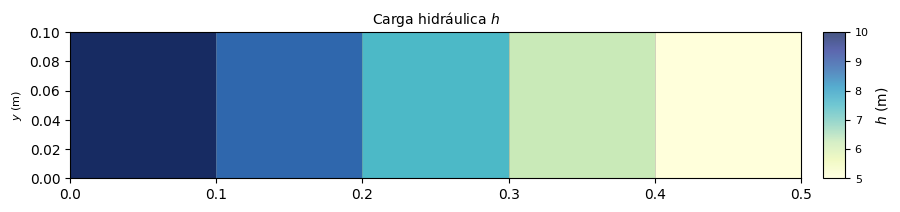

In [11]:
# Ejecutamos la simulación
#o_sim.run_simulation(silent=False)

# --- Recuperamos los resultados de la simulación ---
head = xmf6.gwf.get_head(o_gwf)
qx, qy, qz, n_q = xmf6.gwf.get_specific_discharge(o_gwf)

# --- Parámetros para las gráficas ---
grid = o_gwf.modelgrid
x, y, z = grid.xyzcellcenters
#xlabels = [f'{x:1.1f}' for x in xticks]
#ylabels = [f'{y:1.1f}' for y in yticks]
#kvmin = 1.0 #np.nanmin(k_data)
#kvmax = 0.0 #np.nanmax(k_data)
hvmin = np.nanmin(head)
hvmax = np.nanmax(head)
#qvmin = 0.00 #np.nanmin(n_q)
#qvmax = 0.35 #np.nanmax(n_q)

# --- Definición de la figura ---
fig, ax1 = plt.subplots(1, 1, figsize =(10,10))

# --- Gráfica 1. ---
hview = flopy.plot.PlotMapView(model = o_gwf, ax = ax1)

hview.plot_grid(linewidths = 0.5, alpha = 0.5)

h_ac = hview.plot_array(head, cmap = "YlGnBu", vmin = hvmin, vmax = hvmax, alpha = 0.75)
#hview.contour_array(head, levels = 30, cmap = "bone", linewidths = 1.0)
#ax1.quiver(x, y, qx[0], qy[0], scale = 3, 
#           color = 'k', linewidth = 0.95, pivot = 'middle')
h_cb = plt.colorbar(h_ac, ax = ax1, label = "$h$ (m)", 
                    cax = xmf6.vis.cax(ax1, h_ac))
h_cb.ax.tick_params(labelsize=8)
ax1.set_title("Carga hidráulica $h$", fontsize=10)
ax1.set_ylabel("$y$ (m)", fontsize = 8)
#ax1.set_xticks(ticks = xticks, labels = xlabels, fontsize = 8)
#ax1.set_yticks(ticks = yticks, labels = ylabels, fontsize = 8)
ax1.set_aspect('equal')

plt.show()